<h1><center>Laboratorio 6: ¿A cuanto la casa 🏡?</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Tomás Vallejo Cerda
- Nombre de alumno 2:


### **Link de repositorio de GitHub:** https://github.com/tvallejo11/MDS7202


## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

### Objetivos principales del laboratorio

- Aplicar los conocimientos de preprocesamiento, feature extraction y regresión vistos hasta el momento
- Calcular, aplicar e interpretar métricas de regresión
- Mostrar comprensión sobre el fenómeno de sobreajuste y las implicancias que este tiene, así como formas de evitarlo


El laboratorio deberá ser desarrollado con las herramientas de scikit-learn, incluyendo el uso de pipelines

## Descripción del laboratorio.

Usted acaba de ser contratado por la gran empresa inmobiliaria chilena ***TasAi Ltda.*** Esta empresa maneja una parte importante de las propiedades de Santiago, y buscan aumentar sus ventas mediante un **modelo de pricing** que optimice el valor de venta de las propiedades. Para esto, le han encomendado la tarea de liderar un equipo multidisciplinario de analistas, científicos e ingenieros de datos para analizar datos de características de viviendas de santiago de Chile y sus precios y así poder predecir el valor de venta.

## 1. Pipeline predictivo

### 1.1 EDA [1 ptos]

Don ElIas, CEO de _Tasai_ le presenta a su equipo, los mejores **Data Engineers** de la empresa, quienes mediante técnicas avanzadas de web scrapping de sitios inmobiliarios han logrado construir una base de datos con los precios de venta de viviendas y diversas características de estas, presentes en el archivo `"Precios Casas RM.csv"`. Los data engineers confeccionaron una documentación del dataset, la cual se encuentra en el archivo [documentacion_dataset.md](.\documentacion_dataset.md)

Don ElIas le indica que desean optimizar el modelo de **pricing** de _Tasai_. Para esto, debe utilizar de los datos obtenidos por los data engineers para crear un **modelo predictivo** que permita predecir el precio de venta final de la propiedad en pesos chilenos, presentes en la columna `Price_CLP`.

Su primera tarea será explorar el dataset para entender sus variables y entender cómo procesarlas para entrenar el modelo. Para esto deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Ejecutar la función `profile_dataframe` con el dataframe
- Responder las preguntas que encontrará al final de la secciónn respecto a las distribuciones

In [48]:
import pandas as pd

df = pd.read_csv("Precios Casas RM.csv")

In [49]:
import missingno as msno
import plotly.express as px
from IPython.display import Markdown, display
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_dataframe(df, n_samples=1000, random_state=42):
    display(Markdown("# Analisis columnas"))
    display(Markdown("## Descripcion variables"))
    display(df.describe())
    for col in df.columns:
        serie = df[col].copy()

        profile = pd.Series(dtype="object")
        profile["Type"] = serie.dtype
        profile = pd.concat([profile, serie.describe()])

        # profile = pd.Series([])

        if is_numeric_dtype(serie):
            profile["Negative"] = (serie < 0).sum()
            profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Zeros"] = (serie == 0).sum()
            profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Kurt"] = serie.kurt()
            profile["Skew"] = serie.skew()

        profile[" "] = " "  # espacio

        profile["Missing cells"] = serie.isnull().sum()
        profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
        profile["Duplicate rows"] = serie.duplicated(False).sum()
        profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
        profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

        # profile = pd.concat([profile, description])

        profile = profile.rename(
            index={
                "count": "Number of observations",
                "mean": "Mean",
                "std": "Std",
                "min": "Min",
                "max": "Max",
                "unique": "Unique",
                "top": "Top",
                "freq": "Freq",
            }
        )

        if is_numeric_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}", nbins=48)

        elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

        else:
            count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
            fig = px.bar(
                x=count[serie.name].astype(str),
                y=count["Count"],
                title=f"100 Most common categories of {serie.name}",
            )
        display(Markdown(f"## {serie.name} Profile"))
        display(profile)
        fig.show()

    display(Markdown("# Analisis de nulos"))
    display(Markdown("## Nulos por columna"))
    display(df.isna().sum())
    display(Markdown("## Visualizacion de nulos"))
    msno.matrix(df)
    display(Markdown("## Correlacion de nulidad"))
    msno.heatmap(df)

# Analisis columnas

## Descripcion variables

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,7.779000e+03,7779.000000,7.779000e+03,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000,7.779000e+03
mean,3.642481e+08,10234.571153,4.536091e+05,3.994087,2.653746,229.923669,807.919826,2.980506,9.910828e+06
std,3.868810e+08,10870.491584,4.817945e+05,1.622821,1.465103,1676.898812,9050.893115,17.749384,2.046317e+06
min,2.085000e+03,0.000000,3.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.213620e+06
25%,1.200000e+08,3372.000000,1.494400e+05,3.000000,2.000000,85.000000,129.500000,1.000000,8.563078e+06
50%,2.050000e+08,5760.000000,2.552930e+05,4.000000,2.000000,128.000000,210.000000,2.000000,1.054807e+07
75%,4.911420e+08,13800.000000,6.116340e+05,5.000000,3.000000,200.000000,443.000000,3.000000,1.152463e+07
max,5.516450e+09,155000.000000,6.869801e+06,27.000000,29.000000,120000.000000,678000.000000,1269.000000,1.234149e+07


## Price_CLP Profile

Type                                 int64
Number of observations              7779.0
Mean                      364248117.632086
Std                       386880986.221857
Min                                 2085.0
25%                            120000000.0
50%                            205000000.0
75%                            491142000.0
Max                           5516450000.0
Negative                                 0
Negative (%)                         0.0 %
Zeros                                    0
Zeros (%)                            0.0 %
Kurt                             14.312728
Skew                              2.800394
                                          
Missing cells                            0
Missing cells (%)                    0.0 %
Duplicate rows                        6680
Duplicate rows (%)                 85.87 %
Total size in memory           62364 bytes
dtype: object

...

# Analisis de nulos

## Nulos por columna

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
dtype: int64

## Visualizacion de nulos

## Correlacion de nulidad

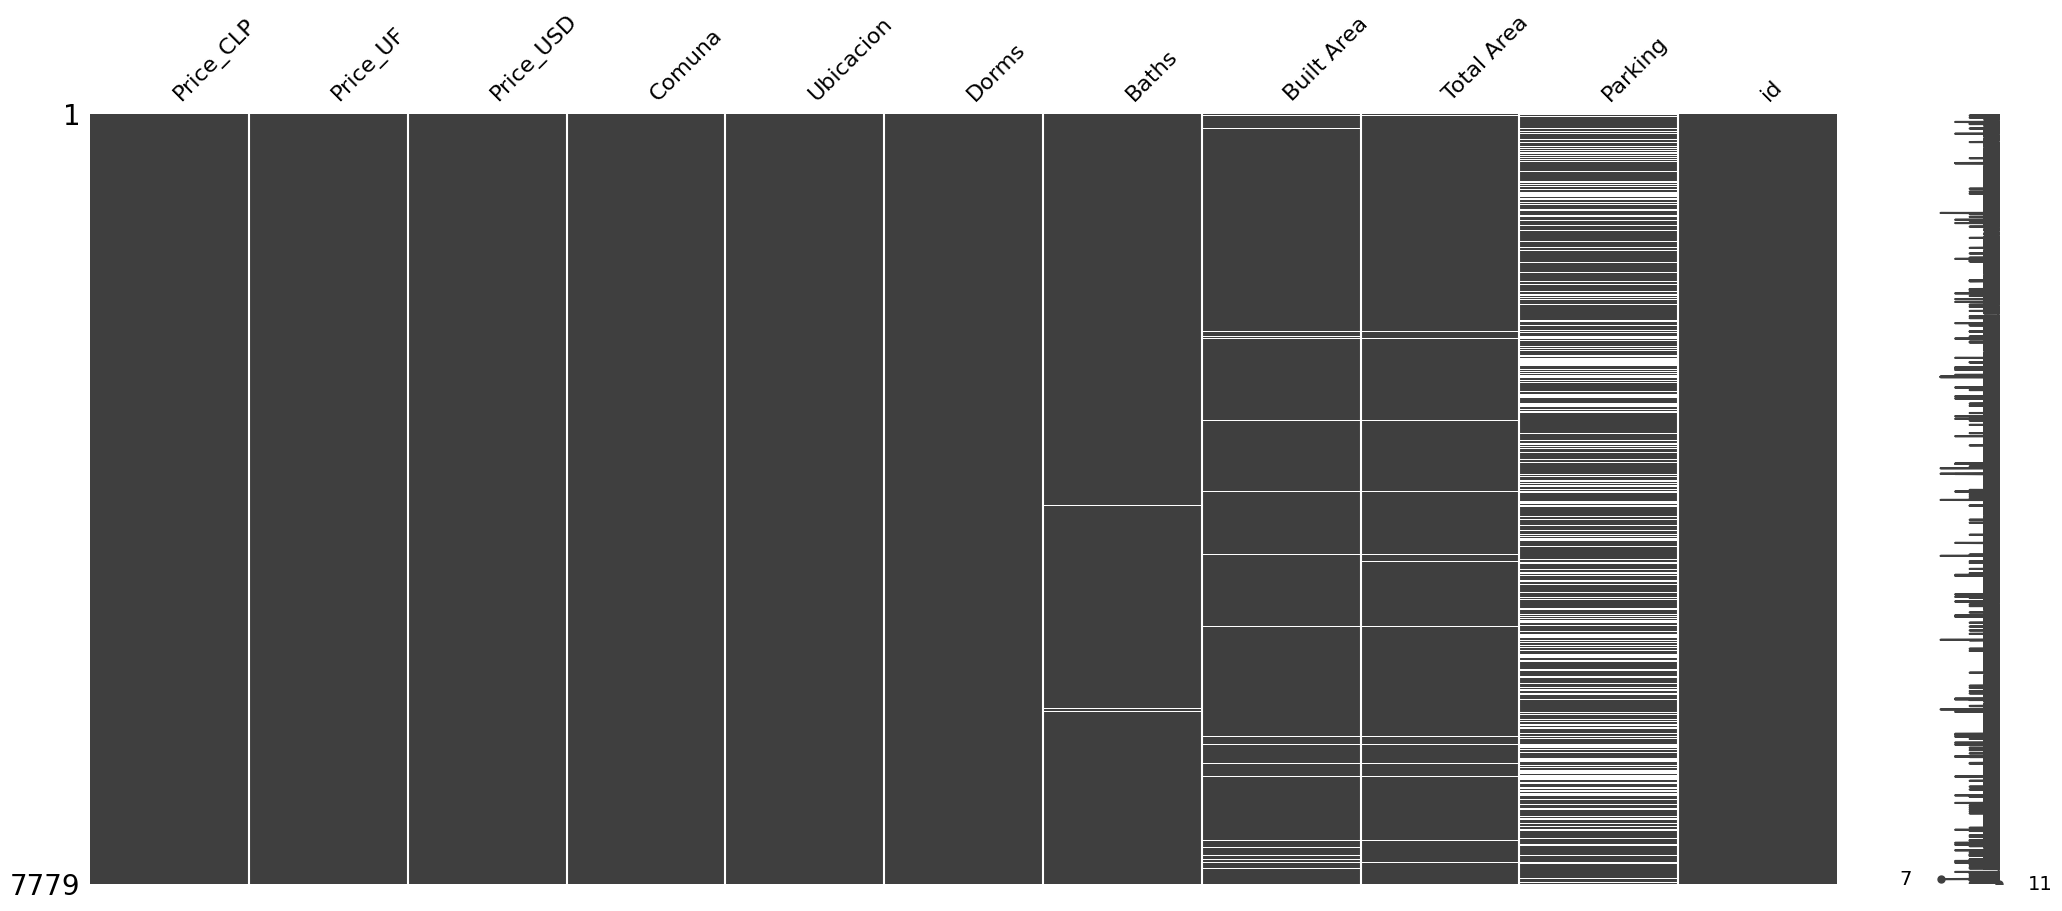

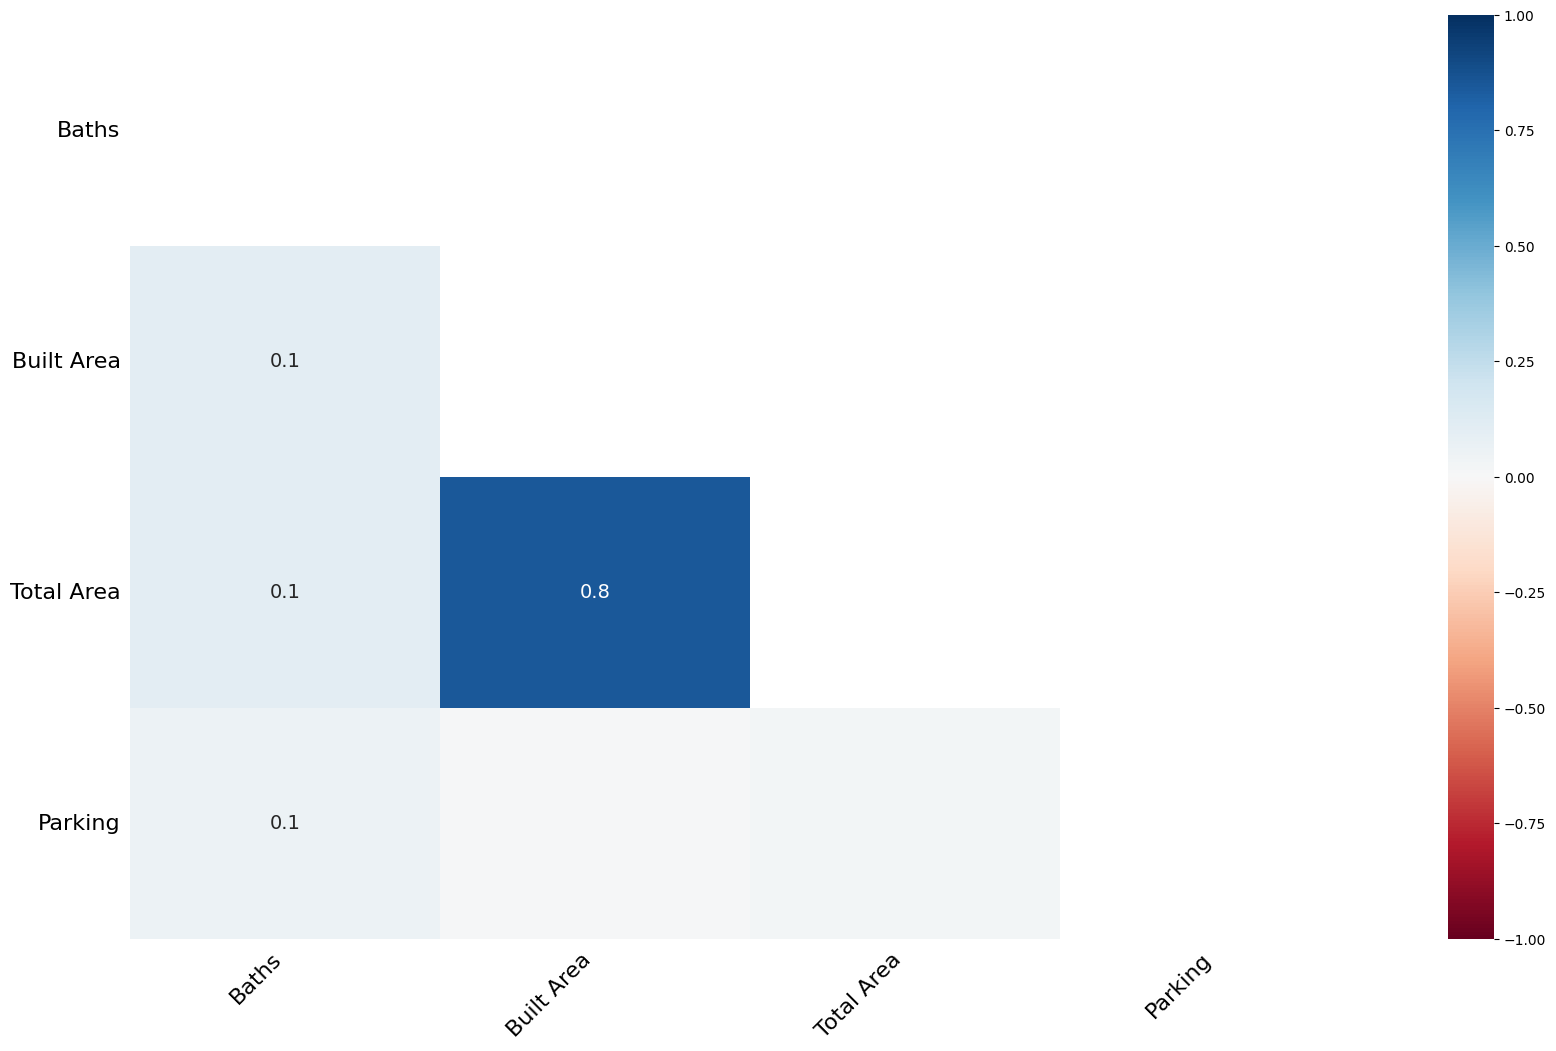

In [50]:
profile_dataframe(df)

Responda las siguientes preguntas (0.2 pts c/u):

1. ¿Cuál es la distribución de la variable objetivo `Price_CLP` en cuanto a tipo de distribución y rangos?
2. Analice las variables categóricas según qué tan útiles son para modelos de machine learning. ¿Qué columnas utilizaría como features y por qué?
3. Para cada variable con nulos, mencione si son nulos porque el dato **no está disponible**, **no aplica** o si realmente **representan un valor determinado**. Pista: considere los rangos observados de cada variable y analice si tiene sentido con el significado de estas presente en la [documentación](.\documentacion_dataset.md).
4. ¿Debería utilizar la columna `id` como feature para entrenar el modelo? ¿Por qué?
5. ¿Se observan valores atípicos? ¿Cuales son?

1. `Price_CLP` tiene una distribución fuertemente sesgada en este caso a la derecha (skew=2.8, kurt=14.3), se evidencia bastante en el histograma donde se apila la mayoría a la izquierda pero existe una cola larga a la derecha, por el mismo lado el valor del kurt indica que que la cola es muy pesada que puede ser debido a outliers muy extremos que se evidencia en el boxplot aunque este comportamiento de colas largas suele ser algo típico de precios de propiedades donde si bien hay un valor de piso no existe techo casi para casas de lujo en los barrios más privilegiados. La mayoría de las casas se concentra entre $120M y $491M CLP (rango intercuartil), con mediana de $205M, pero existe una cola larga de propiedades muy caras que llegan hasta $5.5B CLP. No hay valores negativos ni ceros.

2. `Comuna` es la más útil con 51 categorías manejables que capturan diferencias de precio por ubicación geográfica, por lo que se usaría como feature. `Ubicacion` tiene 6620 valores únicos distintos, lo que la hace prácticamente inútil ya que generaría demasiadas categorías y causaría sobreajuste. `Realtor` tampoco aporta información relevante para predecir el precio de la propiedad, es simplemente quien es el corredor. Por lo tanto, solo se utilizaría `Comuna`.

3. `Baths` (65 nulos, 0.84%): el dato **no está disponible**, probablemente no fue ingresado en el aviso, ya que una casa sin baño no hace mucho sentido. `Built Area` (246 nulos, 3.16%) y `Total Area` (208 nulos, 2.67%): el dato **no está disponible**, falta información en la publicación, además al estudiar la correlación de nulos coinciden en un 80% de los casos, así que se concluye que lo más probable es que simplemente no se haya digitado el valor al no estar disponible (casa sin metros cuadrados tampoco tiene sentido). `Parking` (2290 nulos, 29.44%): los nulos muy probablemente **representan un valor determinado**, específicamente que la propiedad no tiene estacionamiento, dado que el mínimo observado es 1 y la ausencia indicaría 0 estacionamientos, son bastantes datos casi un 30%, además en el análisis de correlación es practicamente 0 con otras variables por lo que no hay sospechas de error de digitación en este caso.

4. No. `id` es un identificador único de la publicación en chilepropiedades.cl y no tiene ninguna relación causal con el precio de la propiedad, no entrega información. Usarlo causaría sobreajuste inmediato ya que el modelo aprendería a memorizar publicaciones específicas en lugar de patrones generales del mercado inmobiliario.

5. Sí. `Built Area` llega a 120,000 m² cuando el 75% tiene menos de 200 m². `Total Area` llega a 678,000 m² cuando el 75% tiene menos de 433 m². `Parking` tiene un máximo de 1,269 estacionamientos cuando el 75% tiene 3 o menos. `Dorms` llega a 27 habitaciones y `Baths` a 29 baños, valores inconsistentes con una casa residencial "normal". `Price_CLP` llega a $5.5B CLP, muy por encima del 75% que está en $491M. Si bien todos estos valores son extremos y probablemente corresponden a errores de ingreso como menciona la documentación, no se puede descartar completamente que algunos sean propiedades reales de lujo, especialmente en el caso del precio.

### 1.2 Preparación de datos [0.75 ptos]

Cree la función `preparacion_de_datos` la cual debe realizar toda la carga y preparación inicial de los datos que no corresponde ir en el pipeline de preprocesamiento. En esta función, ud. deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Eliminar duplicados usando las columnas que estime conveniente
- Eliminar filas nulas, sólo considerando las columnas que su EDA reveló que corresponde eliminar nulos en esas columnas (para algunas puede tener más sentido imputarlas)
- Eliminar valores atípicos (Opcional). Puede aplicar criterio personal a lo que considera atípico.
- Separación del target
- Holdout

Ejecute esta función para obtener ``X_train``, ``X_test``, ``y_train``, ``y_test`` (0.5 ptos)

Luego, justifique su preparación de datos al final de la sección (0.25 ptos)

In [51]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 20968061  # mi rut


def preparacion_de_datos():
    df = pd.read_csv("Precios Casas RM.csv")

    # Eliminar duplicados usando id como identificador único de publicación
    df = df.drop_duplicates(subset=["id"])

    # Eliminar filas con nulos en columnas donde el dato no está disponible
    df = df.dropna(subset=["Baths", "Built Area", "Total Area"])

    # Imputar Parking con 0 ya que definimos que nulo representa "sin estacionamiento"
    df["Parking"] = df["Parking"].fillna(0)

    # Eliminar outliers extremos detectados en el EDA, a criterio de lo observado en los histogramas y boxplots
    df = df[df["Built Area"] <= 2000]
    df = df[df["Total Area"] <= 10000]
    df = df[df["Dorms"] <= 15]
    df = df[df["Baths"] <= 15]
    df = df[df["Parking"] <= 20]
    df = df[df["Price_CLP"] <= 2000000000]

    # Separar target
    X = df.drop(columns=["Price_CLP", "Price_UF", "Price_USD"])
    y = df["Price_CLP"]

    # Holdout 70/30
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, shuffle=True)

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = preparacion_de_datos()
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (5131, 8) | Test: (2200, 8)


Justificar su preparación de datos.
- ¿Qué columnas usó para eliminar nulos y por qué?
- ¿Qué proporción de los datos usó para test y por qué?

**¿Qué columnas usó para eliminar nulos y por qué?**

Se eliminaron las filas con nulos en `Baths`, `Built Area` y `Total Area` ya que como se vío anteriormente en estos casos el dato simplemente no está disponible en la publicación y representan menos del 4% de los datos cada una, por lo que eliminarlas no afecta significativamente el dataset. En cambio, los nulos de `Parking` (29.44%) se imputaron con 0 ya que como se detectó en el EDA, el mínimo observado es 1, lo que indica que la ausencia de valor representa que la propiedad no tiene estacionamiento y no que el dato sea desconocido.

**¿Qué proporción de los datos usó para test y por qué?**

Se utilizó una división 70/30 siguiendo la recomendación vista en la clase 13, donde se establece esta proporción como punto de partida estándar para tener suficientes datos de entrenamiento para que el modelo aprenda patrones generales, mientras se reserva un 30% para evaluar la capacidad de generalizar con datos no vistos.

### 1.3 Preprocesamiento [1 ptos]

Confeccione un `ColumnTransformer` que realice el preprocesamiento de los datos (0.75 ptos). Se recomienda fuertemente basarse en sus observaciones del EDA. El column transformer deberá realizar: 
- Selección de columnas
- Imputación de valores nulos, si los hay
- Escalamiento de variables numéricas
- Encoding de variables categóricas con `one hot encoding`.
- No eliminar la variable `Comuna`

Luego, debe responder las preguntas al final de la sección donde se pide justificar su preprocesamiento. (0.25 ptos)

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# Columnas a usar
NUM_COLS = ["Dorms", "Baths", "Built Area", "Total Area", "Parking"]
CAT_COLS = ["Comuna"]

# Pipeline numérico: imputación mediana + escalamiento robusto
num_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),  # No debiesen haber nulos luego de la limpieza, pero por si acaso en datos nuevos
        ("scaler", RobustScaler()),
    ]
)

#  one hot encoding para las variables categóricas
cat_pipeline = Pipeline(
    steps=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# ColumnTransformer para aplicar los pipelines correspondientes a cada tipo de variable
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, NUM_COLS),
        ("cat", cat_pipeline, CAT_COLS),
    ],
    remainder="drop",  # descarta columnas sobrantes: id, Ubicacion, Realtor
)

Justificar su preprocesamiento.
- ¿Qué columnas eliminó y por qué?
- ¿Por qué escaló los features de esta forma?
- ¿Qué valor(es) usó para imputación y por qué?

Se eliminaron las columnas `id`, `Ubicacion` y `Realtor`, ya que como se analizó anteriormente ninguna aporta información útil para predecir el precio: `id` es solo un identificador de publicación, `Ubicacion` tiene 6620 valores únicos lo que generaría una explosión de dimensiones con one hot encoding causando sobreajuste y sin aporte real a la predicción, `Realtor` no tiene relación con las características físicas de la propiedad. Además se excluyeron `Price_UF` y `Price_USD` por ser transformaciones directas del target, lo que introduciría data leakage. Para el escalamiento se usó `RobustScaler` en las variables numéricas ya que, aunque se eliminaron los outliers más extremos en el paso anterior, las distribuciones siguen siendo asimétricas. Este escalador trabaja con la mediana y el rango intercuartílico, siendo más representativo que `StandardScaler` para este tipo de distribuciones donde la media y la desviación estándar no reflejan bien la tendencia central. Para la imputación también se eligió la mediana por la misma razón, ya que las distribuciones son asimétricas y la mediana no se ve afectada por los valores extremos. Finalmente, para `Comuna` se aplicó `OneHotEncoder` con `handle_unknown="ignore"` para manejar comunas que puedan aparecer en test pero no en train.

### 1.4 Entrenamiento de modelo [0.25 ptos]

A continuación debe crear el `Pipeline` final que incluye el preprocesamiento y el modelo. Para esto usted debe:
- Elegir uno de los modelos vistos en clase: `Regresión lineal`, `Ridge`, `LASSO`, `ElasticNet`
- Crear un pipeline que incluya el preprocesamiento obtenido en la sección anterior y el modelo elegido con hiperparámetros a su elección
- Entrenar pipeline en el dataset de entrenamiento

In [53]:
from sklearn.linear_model import Ridge

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]
)

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### 1.5 Evaluación [1 ptos]

Finalmente llegó el momento de evaluar la capacidad predictiva de su modelo **en datos de test** y demostrarle a don Elias que su trabajo agrega valor a _Tasai_. Para esto, usted deberá:
1. Crear la función `evaluate_model` que reciba el pipeline y los datos de test, realice predicciones y luego calcule las métricas **RMSE**, **MAE** (mean absolute error) y **$R^2$** tanto en datos de **train** como datos de **test**, diferenciándolos mediante prints. (0.2 ptos)

In [54]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    print("--- Train ---")
    print(f"RMSE: {root_mean_squared_error(y_train, y_pred_train):,.0f}")
    print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):,.0f}")
    print(f"R²:   {r2_score(y_train, y_pred_train):.4f}")

    print("\n--- Test ---")
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred_test):,.0f}")
    print(f"MAE:  {mean_absolute_error(y_test, y_pred_test):,.0f}")
    print(f"R²:   {r2_score(y_test, y_pred_test):.4f}")

2. Crear la función `complete_pipeline_v1` que utilice las funciones y objetos definidos anteriorment (`preparacion_de_datos`, el pipeline y `evaluate_model`) de forma que al ejecutarlo se obtengan las métricas del modelo (0.2 ptos)

In [55]:
def complete_pipeline_v1():
    X_train, X_test, y_train, y_test = preparacion_de_datos()
    pipeline.fit(X_train, y_train)
    evaluate_model(pipeline, X_train, X_test, y_train, y_test)

In [56]:
complete_pipeline_v1()

--- Train ---
RMSE: 147,482,720
MAE:  89,145,235
R²:   0.8094

--- Test ---
RMSE: 154,148,673
MAE:  92,155,946
R²:   0.7914


3. Responder las siguientes preguntas (0.15 ptos c/u)
- ¿Qué tan bien el modelo predice el precio de la vivienda? Justifique su respuesta basándose en las 3 métricas obtenidas (debe decir algo de cada métrica)
- ¿Qué diferencia haría elegir un modelo que optimice cada una de las 3 métricas?
- ¿Qué factores pueden haber influido en el desempeño del modelo? Discuta posibles fuentes de error
- Compare las métricas obtenidas con datos de entrenamiento y test. ¿Hubo sobreajuste? Justifique

1. El modelo tiene un desempeño moderado-bueno. El R² de 0.791 en test indica que explica el 79.1% de la varianza en los precios, lo cual es razonable para datos de propiedades con mucho ruido. Sin embargo el RMSE de $154M CLP y el MAE de $92M CLP son errores considerables considerando que la mediana del precio es $205M, lo que significa que en promedio el modelo se equivoca en casi la mitad del precio de una casa típica.

2. Optimizar RMSE penaliza más los errores grandes al elevarlos al cuadrado, lo que entonces conviene cuando los errores extremos son costosos. Optimizar MAE trata todos los errores por igual en valor absoluto, siendo más robusto a outliers y más interpretable directamente en pesos. Optimizar R² busca maximizar la proporción de varianza explicada, lo que da una visión relativa del ajuste pero no dice nada sobre la magnitud real del error en las unidades del problema.

3. El principal factor que afectó el desempeño fue que la relación entre precio y características de una propiedad no es estrictamente lineal, lo que limita inherentemente a Ridge. Además variables como `Ubicacion` fueron descartadas por tener demasiadas categorías, perdiendo información geográfica más detallada que podría mejorar las predicciones, podría existir un trade-off asociado. A pesar del filtrado realizado, las distribuciones asimétricas del precio siguen dificultando el aprendizaje del modelo lineal.

4. Se observa un leve sobreajuste. El modelo obtiene R² de 0.809 en train vs 0.791 en test, y RMSE de $147M vs $154M. La diferencia es pequeña pero consistente en que el modelo rinde mejor en train que en test en todas las métricas, lo que indica un sobreajuste moderado que la regularización de Ridge no elimina completamente pero sí controla.

## 2. Análisis de sobreajuste

Don Elias está contento con sus resultados... pero no tanto. Él piensa que el modelo puede mejorar aún más, por lo que ha decidido contactar a **consultores externos** de la empresa _SuperAI_ para complementar su equipo de trabajo. Los consultores de _SuperAI_ le comentan que consideran que el tratamiento de datos ha sido **subóptimo** debido principalmente a que produce **sobreajuste** y que creen que pueden mejorar el modelo incluyendo datos adicionales sobre las **características socioeconómicas** de las comunas para mitigar el sobreajuste.

### 2.1 Incorporación de datos adicionales [0.5 ptos]

Los consultores de _SuperAI_ le han proporcionado un dataset adicional presente en el archivo `ingresos_por_comuna_2024.xlsx`, el cual contiene la población y el porcentaje de personas en situación de pobreza por comuna. Le encargan **cruzar** estos datos con el dataset principal para incorporar esta información del porcentaje de pobreza en la predicción.

Para esto, usted deberá crear la función `preparacion_de_datos_2`, la cual es una copia de `preparacion_de_datos` pero que incluye la carga del dataset `ingresos_por_comuna_2024.xlsx` y merge con `Precios Casas RM.csv`. Considerar:
- Sólo incorporar la columna `Porcentaje de personas en situacion de pobreza de ingresos 2024` en el dataset
- Renombrar la columna a un nombre más corto
- No modificar nada más de la función original `preparacion_de_datos`

In [57]:
def preparacion_de_datos_2():
    df = pd.read_csv("Precios Casas RM.csv")
    df_comunas = pd.read_excel("ingresos_por_comuna_2024.xlsx")

    # Renombrar columna de pobreza a nombre más corto
    df_comunas = df_comunas.rename(
        columns={
            "Porcentaje de personas en situacion de pobreza de ingresos 2024": "Pobreza",
            "Nombre comuna": "Comuna",  # para hacer merge con dataset principal
        }
    )

    # Merge con dataset principal incorporando solo la columna de pobreza
    df = df.merge(df_comunas[["Comuna", "Pobreza"]], on="Comuna", how="left")

    # Mismo procesamiento que preparacion_de_datos
    df = df.drop_duplicates(subset=["id"])
    df = df.dropna(subset=["Baths", "Built Area", "Total Area"])
    df["Parking"] = df["Parking"].fillna(0)

    df = df[df["Built Area"] <= 2000]
    df = df[df["Total Area"] <= 10000]
    df = df[df["Dorms"] <= 15]
    df = df[df["Baths"] <= 15]
    df = df[df["Parking"] <= 20]
    df = df[df["Price_CLP"] <= 2000000000]

    X = df.drop(columns=["Price_CLP", "Price_UF", "Price_USD"])
    y = df["Price_CLP"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, shuffle=True)

    return X_train, X_test, y_train, y_test

### 2.2 Adaptación del pipeline [0.5 ptos]

Como su función de carga de datos incorpora una nueva columna, se ve obligado a adaptar el resto del pipeline. Adicionalmente, los consultores de _SuperAI_ creen que el modelo todavía puede mejorar, por lo que le solicitan utilizar un procesamiento distinto de la columna `Comuna`. Esta vez, en vez de utilizar **One hot encoding** en la variable **comuna** (o de eliminar la columna si hizo esto), deberá utilizar **Target encoding**. El target encoding es una técnica de feature engineering para procesas variables categóricas donde la variable categórica se remplaza por el promedio de la variable objetivo. Es decir, en este caso se remplaza la comuna por el valor promedio de las propiedades de esa comuna.

Su objetivo en esta sección es crear la función `complete_pipeline_v2` de igual manera que la sección anterior, con las siguientes modificaciones:
- Incluir la nueva variable dentro de las columnas del preprocesamiento numérico
- Utilizar `TargetEncoder(target_type='continuous')` para procesar la variable categórica **comuna**
- Crear la función `complete_pipeline_v2` usando `preparacion_de_datos_2`, el nuevo pipeline y `evaluate_model` (no debería necesitar modificaciones)


In [58]:
from sklearn.preprocessing import TargetEncoder

NUM_COLS_V2 = ["Dorms", "Baths", "Built Area", "Total Area", "Parking", "Pobreza"]
CAT_COLS = ["Comuna"]

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), NUM_COLS_V2),
        ("cat", TargetEncoder(target_type="continuous"), CAT_COLS),
    ],
    remainder="drop",
)

pipeline_v2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        ("model", Ridge(alpha=10.0)),
    ]
)


def complete_pipeline_v2():
    X_train, X_test, y_train, y_test = preparacion_de_datos_2()
    pipeline_v2.fit(X_train, y_train)
    evaluate_model(pipeline_v2, X_train, X_test, y_train, y_test)


complete_pipeline_v2()

--- Train ---
RMSE: 150,743,331
MAE:  93,858,378
R²:   0.8009

--- Test ---
RMSE: 157,837,996
MAE:  97,628,424
R²:   0.7813


/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3217192244060863e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


### 2.3 Comparación de resultados [0.5 ptos]

Finalmente, habiendo construido 2 pipelines diferentes para abordar el mismo problema, don Elias está ansioso por ver los resultados.

- Ejecutar `complete_pipeline_v1` y `complete_pipeline_v2`
- Comparar las métricas y comentar los resultados. ¿Qué modelo considera que le fue mejor?

In [59]:
print("=== Pipeline V1 ===")
complete_pipeline_v1()

print("\n=== Pipeline V2 ===")
complete_pipeline_v2()

=== Pipeline V1 ===
--- Train ---
RMSE: 147,482,720
MAE:  89,145,235
R²:   0.8094

--- Test ---
RMSE: 154,148,673
MAE:  92,155,946
R²:   0.7914

=== Pipeline V2 ===
--- Train ---
RMSE: 150,740,329
MAE:  93,883,907
R²:   0.8009

--- Test ---
RMSE: 157,843,421
MAE:  97,652,358
R²:   0.7813


/Users/tomasvallejo/Documents/Universidad/Otoño 2026/MDS7202/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3309105148610758e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Al comparar ambos pipelines, v1 obtuvo mejores métricas en todas las dimensiones: RMSE de $154M vs $158M, MAE de $92M vs $98M y R² de 0.791 vs 0.781. Sorprendentemente, las modificaciones propuestas por los consultores no mejoraron el modelo sino que lo empeoraron levemente.

### 2.4 Discusión [0.5 ptos]

1. Considerando los resultados obtenidos mencione al menos 2 razones de por qué cree que a uno de los modelos le fue mejor que a otro. ¿Cómo se relaciona con el fenómeno de sobreajuste?

El modelo v1 fue mejor. La hipótesis de que agregar información socioeconómica y target encoding mejoraría las predicciones no se cumplió en la práctica. Una explicación es que el OneHotEncoder de v1 daba al modelo 51 columnas para distinguir comunas con mayor granularidad, mientras que el target encoding colapsa esa información en un solo valor perdiéndola, y la variable `Pobreza` no aportó información nueva ya que la ubicación por comuna ya capturaba implícitamente las diferencias socioeconómicas. Respecto al sobreajuste, la afirmación de los consultores tampoco se sostiene completamente: v1 obtiene R² de 0.809 en train y 0.791 en test, mostrando un leve sobreajuste pero bien controlado por la regularización de Ridge. V2 en cambio al reducir la complejidad de 56 a 7 parámetros cayó en el problema opuesto: subajuste, capturando menos estructura real de los datos con R² de 0.801 en train y 0.781 en test.

2. Determine la cantidad de parámetros (complejidad) de los 2 modelos entrenados usando `pipeline.steps[...]` para obtener el modelo y luego imprimiendo el largo del atributo `coef_`. Luego, considerando las métricas de ambos modelos y la complejidad ¿Qué puede decir sobre el tratamiento de datos del segundo pipeline? Justifique

In [60]:
# Complejidad de cada modelo
coef_v1 = pipeline.steps[-1][1].coef_
coef_v2 = pipeline_v2.steps[-1][1].coef_

print(f"Parámetros v1: {len(coef_v1)}")
print(f"Parámetros v2: {len(coef_v2)}")

Parámetros v1: 55
Parámetros v2: 7


V1 tiene 55 parámetros mientras que v2 solo tiene 7. Esto confirma el análisis anterior: v1 con OneHotEncoder generaba 50 columnas de comunas más 5 numéricas, dándole al modelo más información para aprender. V2 con target encoding redujo drásticamente la complejidad a solo 7 parámetros, siendo demasiado simple para capturar las diferencias de precio entre comunas. En este caso el tratamiento de datos del segundo pipeline fue subóptimo, ya que al reemplazar OHE por target encoding se perdió información valiosa y la variable `Pobreza` no compensó esa pérdida. Dicho esto, ambos modelos siguen siendo lineales y tienen limitaciones inherentes para este problema, un modelo no lineal probablemente capturaría mejor las relaciones entre características y precio, superando a Ridge independientemente del preprocesamiento utilizado.